# Ejercicios extra 
Para practicar lo que vimos en clase. Hay **6 ejercicios**: 3 de redes neuronales con Keras y 3 de YOLO. No son difíciles; con repasar el notebook de clase os salen.

**Instrucciones**
- Resuelve cada ejercicio en la celda que pone `# TODO`.
- No tienen que salir perfectos: lo importante es practicar el flujo.
- Cada ejercicio trae **pistas** y te dice a qué bloque de clase se parece.

## Preparación (ejecuta esto antes de empezar)

In [1]:
# Instala lo necesario (solo la primera vez; si ya lo tienes, no pasa nada).
%pip install tensorflow matplotlib numpy scikit-learn ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# (Windows) por si imprimes algun emoji en un print, evita errores de codificacion:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

print('Listo para empezar. A practicar!')

Listo para empezar. A practicar!


# Parte A — Redes Neuronales (Keras)

## Ejercicio 1 — El flujo completo con MNIST

Repite tú solo, de principio a fin, lo que hicimos en clase con los dígitos. Pasos:

1. Carga **MNIST** y **normaliza** (divide las imágenes entre 255).
2. Construye una red `Sequential`: `Input(28,28)` → `Flatten` → `Dense(128, 'relu')` → `Dense(10, 'softmax')`.
3. Compila con `optimizer='adam'`, `loss='sparse_categorical_crossentropy'`, `metrics=['accuracy']`.
4. Entrena **5 epochs**.
5. Evalúa en el conjunto de **test** e imprime el accuracy.
6. Predice **5 imágenes** del test y muéstralas con el dígito que dice la red.

 **Objetivo:** superar el **95%** en test.


In [3]:
# Ejercicio 1 - El flujo completo con MNIST
# Pasos: cargar -> normalizar -> construir -> compilar -> entrenar -> evaluar -> predecir

import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)
print('NumPy      :', np.__version__)
print('Todo OK. (La CPU es suficiente para la clase de hoy.)')

TensorFlow : 2.21.0
Keras      : 3.14.1
NumPy      : 2.2.6
Todo OK. (La CPU es suficiente para la clase de hoy.)


Imagenes de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imagenes de test: (10000, 28, 28)
Primeras 10 etiquetas: [5 0 4 1 9 2 1 3 1 4]


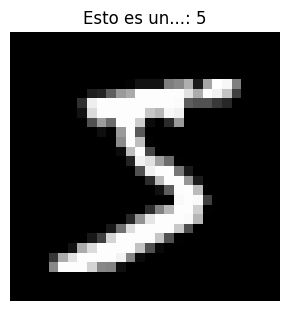

In [4]:
# Cargamos el dataset de MNIST
keras.datasets.mnist.load_data() # devuelve dos tuplas: la primera contiene los datos de entrenamiento (X_train, y_train)
# y la segunda contiene los datos de prueba (X_test, y_test).

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Imagenes de entrenamiento:', X_train.shape)
print('Etiquetas de entrenamiento:', y_train.shape)
print('Imagenes de test:', X_test.shape)
print('Primeras 10 etiquetas:', y_train[:10])

plt.figure(figsize=(3.5, 3.5))
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Esto es un...: {str(y_train[0])}')
plt.axis('off')
plt.show()

In [ ]:
print(X_train[0][4:16, 6:20]) # muestra una parte de la imagen del primer dígito (un 5) para que veamos los valores numéricos de los píxeles.
print()
print("Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   3  18  18  18 126 136 175  26]
 [  0   0  30  36  94 154 170 253 253 253 253 253 225 172]
 [  0  49 238 253 253 253 253 253 253 253 253 251  93  82]
 [  0  18 219 253 253 253 253 253 198 182 247 241   0   0]
 [  0   0  80 156 107 253 253 205  11   0  43 154   0   0]
 [  0   0   0  14   1 154 253  90   0   0   0   0   0   0]
 [  0   0   0   0   0 139 253 190   2   0   0   0   0   0]
 [  0   0   0   0   0  11 190 253  70   0   0   0   0   0]
 [  0   0   0   0   0   0  35 241 225 160 108   1   0   0]
 [  0   0   0   0   0   0   0  81 240 253 253 119  25   0]
 [  0   0   0   0   0   0   0   0  45 186 253 253 150  27]]

Cada pixel tiene un valor entre 0 y 255, donde 0 representa el color negro y 255 representa el color blanco. Los valores intermedios representan diferentes tonos de gris.


In [ ]:
# Normalizamos los datos
X_train = X_train /255.0 # Normalizamos los valores de los píxeles a un rango de 0 a 1
X_test = X_test /255.0
print('Listo. Ahora los datos están normalizados.', X_train.min(), 'a', X_train.max())

Listo. Ahora los datos están normalizados. 0.0 a 1.0


## Ejercicio 1 — El flujo completo con MNIST

Repite tú solo, de principio a fin, lo que hicimos en clase con los dígitos. Pasos:

1. Carga **MNIST** y **normaliza** (divide las imágenes entre 255).
2. Construye una red `Sequential`: `Input(28,28)` → `Flatten` → `Dense(128, 'relu')` → `Dense(10, 'softmax')`.
3. Compila con `optimizer='adam'`, `loss='sparse_categorical_crossentropy'`, `metrics=['accuracy']`.
4. Entrena **5 epochs**.
5. Evalúa en el conjunto de **test** e imprime el accuracy.
6. Predice **5 imágenes** del test y muéstralas con el dígito que dice la red.

 **Objetivo:** superar el **95%** en test.


In [7]:
modelo = keras.Sequential([

    keras.layers.Input(shape=(28, 28)), # ENTRADA: Imagenes de 28x28 pixeles
    keras.layers.Flatten(), # APLANAR, convierte la matriz de 28x28 en una fila de 784 elementos numeros
                            # (las capas DENSE necesitan trabajar con vectores)

    keras.layers.Dense(128, activation='relu'),  # CAPA OCULTA "densa": 128 neuronas conectadas al 784 del vector.
                                                 # DENSE = Cada neurona se conecta a TODAS las entradas.
                                                 # activacion relu es la "chispa" no lineal que permite aprender formas complejas
                                                 # sin ella la red solo sabría hacer rectas.
           
    keras.layers.Dense(10, activation='softmax') # CAPA DE SALIDA: 10 neuronas (una por digito  0-9).
                                                 # softmax convierte las 10 salidas en probabilidades que suman 1.
])


modelo.compile(
    optimizer='adam', # Adam # es un algoritmo de optimización que ajusta los pesos de la red para minimizar la función de pérdida.
    loss='sparse_categorical_crossentropy', # Función de pérdida para clasificación multi-clase
    metrics=['accuracy'] # Métrica para evaluar el rendimiento
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# fit es el método que se encarga de entrenar el modelo. Toma los datos de entrenamiento (X_train, y_train) y los utiliza para ajustar los pesos de la red neuronal.
# Entrenamos el modelo con los datos de entrenamiento, durante 5 épocas, y reservamos el 10% de los datos para validación.
historia = modelo.fit(X_train, y_train, epochs=5, validation_split=0.1)  

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9204 - loss: 0.2767 - val_accuracy: 0.9657 - val_loss: 0.1298
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9637 - loss: 0.1242 - val_accuracy: 0.9730 - val_loss: 0.0962
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9747 - loss: 0.0843 - val_accuracy: 0.9767 - val_loss: 0.0861
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9800 - loss: 0.0645 - val_accuracy: 0.9785 - val_loss: 0.0810
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9847 - loss: 0.0495 - val_accuracy: 0.9775 - val_loss: 0.0762


In [9]:
# evaluate es el método que se encarga de evaluar el rendimiento del modelo en un conjunto de datos de prueba (X_test, y_test).
# Devuelve la pérdida y la precisión.
# verbose=0 es para que no imprima el progreso de la evaluación.

test_acc = modelo.evaluate(X_test, y_test, verbose=0)[1]
print('Accuracy en test:', test_acc * 100, '%')
print('Es decir: acierta', round(test_acc*100), 'de cada 100 digitos que nunca habia visto')

Accuracy en test: 97.35999703407288 %
Es decir: acierta 97 de cada 100 digitos que nunca habia visto


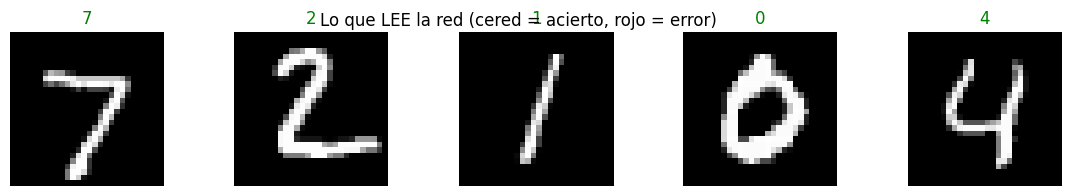

In [10]:
# predict es el método que se encarga de hacer predicciones con el modelo entrenado. Toma un conjunto de datos (X_test) y devuelve las probabilidades de cada clase para cada muestra.
preds = modelo.predict(X_test[:5], verbose=0)#las 5 primeras imagenes del test, para ver que lee la red

fig, ax = plt.subplots(1, 5, figsize=(14, 2))  #crea 5 minigraficos para mostrar las 5 primeras imagenes del test, y lo que lee la red
for k in range(5): #recorre las 5 primeras imagenes del test
    p = int(np.argmax(preds[k])) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen
    ax[k].imshow(X_test[k], cmap='gray') #muestra la imagen del test
    color = 'green' if p == y_test[k] else 'red' #si la prediccion es correcta (p == y_test[k]) el titulo se muestra en verde, sino en rojo
    ax[k].set_title(str(p), color=color) #titulo del grafico es la prediccion de la red, con el color correspondiente
    ax[k].axis('off')

plt.suptitle('Lo que LEE la red (cered = acierto, rojo = error)')
plt.show()

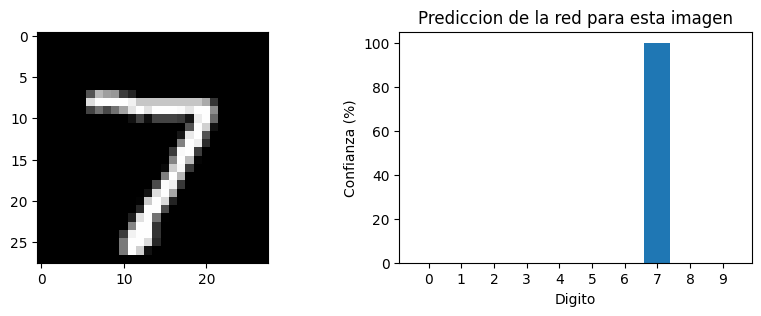

In [11]:
i=0

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test

fig, ax = plt.subplots(1, 2, figsize=(10, 3)) #crea dos minigraficos para mostrar la imagen del test y las probabilidades de cada clase
ax[0].imshow(X_test[i], cmap='gray') #muestra la imagen del test
ax[1].bar(range(10), probs*100) #muestra un grafico de barras con las probabilidades de cada clase
ax[1].set_xticks(range(10)) #pone los numeros del 0 al 9 en el eje x del grafico de barras
ax[1].set_xlabel('Digito'); ax[1].set_ylabel('Confianza (%)')
ax[1].set_title('Prediccion de la red para esta imagen')
plt.show()

Elige una imagen cualquiera del test (cambia el índice `i`), **predícela** y responde en el chat:
1. ¿Qué dígito dice la red?
2. ¿Con qué % de confianza?
3. ¿Acierta?

Imagen del test numero 350 la red dice 1 con una confianza del 100.0 % y la etiqueta real es 1


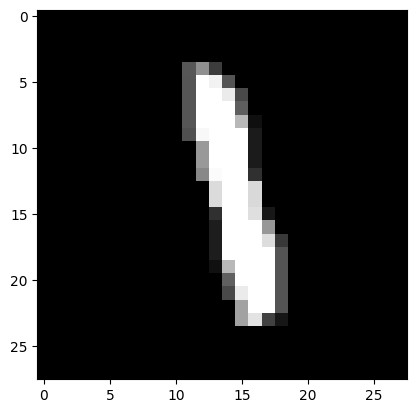

In [12]:
i = 350

probs = modelo.predict(X_test[i:i+1], verbose=0)[0] #predice la probabilidad de cada clase para la imagen i del test
pred = int(probs.argmax()) #argmax devuelve el indice de la clase con mayor probabilidad, es decir, lo que la red "cree" que es cada imagen

print('Imagen del test numero', i, 'la red dice', pred, 'con una confianza del',
       round(float(probs[pred])*100, 1), '%', 'y la etiqueta real es', y_test[i])

plt.imshow(X_test[i], cmap='gray')
plt.show()

## Ejercicio 2 — ¿Cuánta red hace falta?

Entrena **tres** redes distintas sobre MNIST y compara su accuracy en test:

- **A)** 1 capa oculta de **32** neuronas
- **B)** 1 capa oculta de **128** neuronas
- **C)** **2** capas ocultas de **128** neuronas

Imprime el accuracy de cada una y responde en un comentario:
> ¿Cuál gana? ¿Merece la pena la más grande, o casi dan lo mismo?


In [ ]:
# Ejercicio 2 - Compara 3 arquitecturas (32 / 128 / 128+128) y mira cual gana

# TODO

## Ejercicio 3 — ¿Qué confunde tu red? (con ropa)

Ahora con **Fashion-MNIST** (`keras.datasets.fashion_mnist`), donde las etiquetas 0–9 son tipos de ropa.

1. Entrena una red con el **mismo flujo** de siempre.
2. Predice **todo** el test y dibuja la **matriz de confusión** (`from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay`).
3. Mira la matriz y escribe en un comentario **qué dos prendas confunde más** la red.
4. Muestra **3 imágenes mal clasificadas** con un título tipo `dice X / es Y`.


In [ ]:
# Ejercicio 3 - Matriz de confusion y errores con Fashion-MNIST
# Esta lista traduce cada etiqueta (0-9) a su nombre, por si la necesitas:
clases = ['Camiseta/top', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botin']

# TODO

# Parte B — YOLO

> En esta parte **no entrenamos nada**: usamos un modelo de YOLO que ya viene entrenado. Es lo que vimos en el remate de clase.

## Ejercicio 4 — Detecta objetos en una imagen

1. Carga el modelo: `modelo = YOLO('yolo11n.pt')` (se descarga solo la primera vez).
2. Pásale una imagen: la de ejemplo `foto.jpg` (te la prepara la celda de abajo) **o** una tuya guardada como `mi_foto.jpg`.
3. Muestra la imagen con las cajas dibujadas usando `resultado[0].plot()`. Recuerda pasar de BGR a RGB con `[:, :, ::-1]`.
4. Imprime la lista de objetos detectados.


In [ ]:
# Ejercicio 4 - Detecta objetos en una imagen
from ultralytics import YOLO
import urllib.request, os

# Preparamos una imagen de ejemplo (si no tienes una propia):
if not os.path.exists('foto.jpg'):
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', 'foto.jpg')


# TODO

## Ejercicio 5 — Cuenta cuántas personas hay

Usando YOLO sobre una imagen con gente (la de ejemplo `foto.jpg` sirve), **cuenta cuántas personas** detecta e imprime un mensaje tipo:
> `Hay 4 personas en la imagen`

💡 *Pista: recorre `resultado[0].boxes.cls`. Cada valor es el número de una clase; su nombre lo da `modelo.names[int(c)]`. Cuenta cuántos son `'person'`. (También puedes hacerlo con una lista por comprensión si te animas.)*

In [ ]:
# Ejercicio 5 - Cuenta las personas detectadas

# TODO

## Ejercicio 6 — El umbral de confianza (`conf`)

YOLO solo muestra las detecciones cuya **confianza** supera un umbral llamado `conf` (por defecto, 0.25). Vamos a jugar con él:

1. Corre YOLO sobre la misma imagen con `modelo('foto.jpg', conf=0.25)` y mira **cuántos objetos** detecta.
2. Corre otra vez con `conf=0.7` y cuenta de nuevo.
3. Escribe en un comentario: ¿con cuál detecta **más** objetos? ¿Por qué crees que pasa?

💡 *Pista: `len(resultado[0].boxes)` te dice cuántos objetos ha detectado. Subir el umbral = la red se vuelve más exigente y solo enseña lo que ve muy claro.*
⭐ *Bonus: prueba un modelo más grande con `YOLO('yolo11s.pt')` ('s' = small) y mira si detecta más cosas que el `'n'` (nano).*

In [ ]:
# Ejercicio 6 - Compara conf=0.25 vs conf=0.7

# TODO